In [3]:
%load_ext autoreload
%autoreload 2

import os
import sys
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
from data_processing import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**GENERAL PROCEDURE**

-1) This runs at the leica-env<br />
0) Use the loader2 function to extract images from Leica file system
1) Launch napari (in a different terminal start micro-sam conda env (conda activate micro-sam) and there launch napari (just type napari, then Enter)).
2) Load images in Napari: File, Load Files as Stack...
3) Find the frames where the Antennal Lobes (AL) are visible before .
4) Make masks out of these selected frames by:
    a)

In [2]:
loader2('2026_05_26','Gerardo',True, False)

/home/gerard/data/confocal/2026_05_26_Gerardo
Number of series: 3
series 0: shape = (1, 3, 110, 512, 512)
series 1: shape = (1, 3, 110, 512, 512)
series 2: shape = (1, 3, 18, 512, 512)


In [32]:
dictMD = parse_lif_psf_params('/home/gerard/data/confocal/2026_05_26_Gerardo/Project.lif', scene=0)
print(dictMD)
dictMD = parse_lif_psf_params('/home/gerard/data/confocal/2026_05_26_Gerardo/Project.lif', scene=1)
print(dictMD)
dictMD = parse_lif_psf_params('/home/gerard/data/confocal/2026_05_26_Gerardo/Project.lif', scene=2)
print(dictMD)
dictMD = parse_lif_psf_params('/home/gerard/data/confocal/2025_12_06_Gerardo/Project.lif', scene=2)
print(dictMD)


{'NA': 1.4, 'n': 1.518, 'voxel_z_um': 0.5344549541284404, 'voxel_xy_um': 0.36110332681017615, 'emission_nm': [529.0, 659.0, 796.5]}
{'NA': 1.4, 'n': 1.518, 'voxel_z_um': 0.29222, 'voxel_xy_um': 0.022568962818003916, 'emission_nm': [529.0, 659.0, 796.5]}
{'NA': 1.4, 'n': 1.518, 'voxel_z_um': 0.66134, 'voxel_xy_um': 0.022568962818003916, 'emission_nm': [529.0, 659.0, 796.5]}
{'NA': 1.3, 'n': 1.518, 'voxel_z_um': 0.9997, 'voxel_xy_um': 0.7109223091976516, 'emission_nm': [602.5, 716.0, 796.5]}


In [34]:
from aicsimageio import AICSImage
img = AICSImage('/home/gerard/data/confocal/2026_05_26_Gerardo/Project.lif')
img.set_scene(img.scenes[1])          # scene index matches the one you pass to deconvolve



In [37]:
stack = img.get_image_data("ZYX", T=0, C=0)
result = deconvolve(stack, '/home/gerard/data/confocal/2026_05_26_Gerardo/Project.lif', channel=0, scene=1)



PSF (ch0): λ=529 nm | σ_xy=0.079 µm (3.52 px) | σ_z=0.270 µm (0.93 px)


In [ ]:
imwrite('deconv_ch0.tif', result, imagej=True, resolution=(1/vxy, 1/vxy),
        metadata={'spacing': vz, 'unit': 'um', 'axes': 'ZYX'})

In [38]:
print(type(result
           ))

<class 'numpy.ndarray'>


In [ ]:
dictMD = parse_lif_psf_params('/home/gerard/data/confocal/2026_05_26_Gerardo/Project.lif', scene=0)
print(dictMD)

**WHAT IS EACH SERIES OBTAINED PREVIOUSLY**<br />
numbers correspond to notebooks's map:<br />
**--5X training**<br />
series_0: brain 1, ALL<br />
series_1: brain 2, ALL<br />
series_2: brain 3, ALL<br /><br />


series_3: brain 3, MB<br />
series_4: brain 2, MB<br />
series_5: brain 1, MB<br />
series_6: brain 4, MB<br />
series_7: brain 5, MB<br /><br />

**--1X training**<br />
series_8: brain 6, MB<br />
series_9: brain 7, MB<br />
series_10: brain 8, MB<br />
series_11: brain 9, MB<br />


**Frames used as mask for the Antennal Lobe (AL), MB alpha lobe (MBa)**<br />
series_5: brain 1 MB: <br />
-AL: [0,7]<br />
-MBa : [14,41] <br />

series_3: brain 3 MB: <br />
-AL: [0,8]<br />
-MBa : [14,37] <br />

series_8: brain 6, MB:<br />
-AL: [0,8]<br />
-MBa : [16,40] <br />



In [78]:
def basic_ratios(series_n):
    
    series = 'series_' + str(series_n)
    s = 's' + str(series_n)
    
    results = {}
    results['brp'] = {}
    results['mito'] = {}
    results['hsp'] = {}
    
    msk_AL = f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/masks/msk_AL.tif'
    msk_MBa = f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/masks/msk_MBa.tif'
    
    
    al = signal_extractor(msk_AL, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch0_AL.tif')
    brp = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch0_MBa.tif')
    mito = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch1_MBa.tif')
    hsp = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch2_MBa.tif')
    
    denominatorL = al['0']['1']
    denominatorR = al['0']['2']
    
    results['brp']['a1'] = brp['0']['1'] / denominatorL, brp['0']['4'] / denominatorR
    results['brp']['a2'] = brp['0']['2'] / denominatorL, brp['0']['5'] / denominatorR
    results['brp']['a3'] = brp['0']['3'] / denominatorL, brp['0']['6'] / denominatorR

    results['mito']['a1'] = mito['0']['1'] / denominatorL, mito['0']['4'] / denominatorR
    results['mito']['a2'] = mito['0']['2'] / denominatorL, mito['0']['5'] / denominatorR
    results['mito']['a3'] = mito['0']['3'] / denominatorL, mito['0']['6'] / denominatorR
 
    
    results['hsp']['a1'] = hsp['0']['1'] / denominatorL, hsp['0']['4'] / denominatorR
    results['hsp']['a2'] = hsp['0']['2'] / denominatorL, hsp['0']['5'] / denominatorR
    results['hsp']['a3'] = hsp['0']['3'] / denominatorL, hsp['0']['6'] / denominatorR
    

    
    
    return results




In [5]:

def raw_values(series_n):
    
    series = 'series_' + str(series_n)
    s = 's' + str(series_n)
    
    results = {}
    results['brp'] = {}
    results['mito'] = {}
    results['hsp'] = {}
    
    msk_AL = f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/masks/msk_AL.tif'
    msk_MBa = f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/masks/msk_MBa.tif'
    
    
    al = signal_extractor(msk_AL, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch0_AL.tif')
    brp = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch0_MBa.tif')
    mito = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch1_MBa.tif')
    hsp = signal_extractor(msk_MBa, f'/home/gerard/data/confocal/2025_11_29_Gerardo/{series}/projections/2025_11_29_{s}_ch2_MBa.tif')
    
    
    results['brp']['a1'] = brp['0']['1'], brp['0']['4']
    results['brp']['a2'] = brp['0']['2'], brp['0']['5'] 
    results['brp']['a3'] = brp['0']['3'], brp['0']['6']

    results['mito']['a1'] = mito['0']['1'], mito['0']['4']
    results['mito']['a2'] = mito['0']['2'], mito['0']['5']
    results['mito']['a3'] = mito['0']['3'], mito['0']['6']
 
    
    results['hsp']['a1'] = hsp['0']['1'], hsp['0']['4']
    results['hsp']['a2'] = hsp['0']['2'], hsp['0']['5']
    results['hsp']['a3'] = hsp['0']['3'], hsp['0']['6']
    
    
    results['al'] =  al['0']['1'], al['0']['2']
    

    
    
    return results


# def plot_bars_with_sem3(groups, labels=None, ylabel="Value", figsize=(3,6),
#                        bar_color="lightgray", pattern = '', dot_color="black", spine_width=2):
#     """
#     Plot multiple groups as bars with SEM and overlay individual data points.

#     Parameters
#     ----------
#     groups : list of array-like
#         List of numeric arrays/lists, one per group.
#     labels : list of str, optional
#         Labels for each group (x-axis).
#     ylabel : str, optional
#         Label for y-axis.
#     figsize : tuple, optional
#         (width, height) of the figure in inches.
#     bar_color : str, optional
#         Color of the bars.
#     dot_color : str, optional
#         Color of the overlaid dots.
#     spine_width : float, optional
#         Thickness of the axis spines.
#     """

#     groups = [np.asarray(g) for g in groups]
#     n_groups = len(groups)

    
#     means = [np.nanmean(g) for g in groups]
#     sems  = [np.nanstd(g, ddof=1) / np.sqrt(np.sum(~np.isnan(g))) for g in groups]
    
#     for i,lbl in enumerate(labels):
#         print(f"group: {lbl}, mean: {means[i]}, sem: {sems[i]}")
#     if labels is None:
#         labels = [f"Group {i+1}" for i in range(n_groups)]

#     fig, ax = plt.subplots(figsize=figsize)
#     x = np.arange(n_groups)
#     if len(bar_color) > 1:
#         if len(bar_color) != n_groups:
#            num_groups = n_groups / len(bar_color)
#            bar_color = bar_color * int(num_groups)
           
#     if len(pattern) > 1:
#         if len(pattern) != n_groups:
#            num_groups = n_groups / len(pattern)
#            pattern = pattern * int(num_groups)
#             # raise ValueError("Length of bar_color list must match number of groups.")
#         # bar_colors = bar_color
#     # Bars + SEM
#     ax.bar(x, means, yerr=sems, capsize=8,
#            color=bar_color, edgecolor="black",hatch = pattern, linewidth=1.5)

#     # Overlay dots
#     for i, vals in enumerate(groups):
#         # jitter = (np.random.rand(len(vals)) - 0.5) * 0.2
#         jitter = 0
#         ax.scatter(np.full(len(vals), x[i]) + jitter, vals,
#                    color=dot_color, s=40, alpha=0.8, zorder=3)

#     # Axis labels & limits
#     ax.set_xticks(x)
#     ax.set_xticklabels(labels)
#     ax.set_ylabel(ylabel)

#     # --- Style adjustments ---
#     # Thicker left & bottom spines, remove top/right
#     for spine in ["left", "bottom"]:
#         ax.spines[spine].set_linewidth(spine_width)
#     for spine in ["top", "right"]:
#         ax.spines[spine].set_visible(False)

#     # Ticks only on left/bottom
#     ax.yaxis.set_ticks_position("left")
#     ax.xaxis.set_ticks_position("bottom")

#     # Add baseline at y = 0
#     ax.axhline(0, color="black", linewidth=1.2)

#     plt.tight_layout()
#     return ax

In [79]:
##### 5x
br1 = basic_ratios(5)
print(f"brp: {br1['brp']}")
print(f"mito: {br1['mito']}")
print(f"hsp: {br1['hsp']}")

br2 = basic_ratios(4)
br3 = basic_ratios(3)
br4 = basic_ratios(6)
br5 = basic_ratios(7)
##### 1x
br6 = basic_ratios(8)
br7 = basic_ratios(9)
br8 = basic_ratios(10)
br9 = basic_ratios(11)



brp: {'a1': (1.4390992243810716, 1.0192951947801012), 'a2': (1.3151030949243543, 0.9835160044961796), 'a3': (1.6554100474893332, 1.3319711414063926)}
mito: {'a1': (2.2666317376997807, 1.6620442621245224), 'a2': (1.8744109940230995, 1.4288001735647795), 'a3': (1.5422432080611335, 1.456711295919055)}
hsp: {'a1': (9.658919128016295, 6.750244496960509), 'a2': (9.341900979033651, 7.097527034644409), 'a3': (12.75473085360268, 9.647276695614874)}


In [80]:
# RAW
##### 5x
brr1 = raw_values(5)
brr2 = raw_values(4)
brr3 = raw_values(3)
brr4 = raw_values(6)
brr5 = raw_values(7)
##### 1x
brr6 = raw_values(8)
brr7 = raw_values(9)
brr8 = raw_values(10)
brr9 = raw_values(11)





In [81]:
print(brr1)

{'brp': {'a1': (8.9125, 7.038095238095238), 'a2': (8.144578313253012, 6.791044776119403), 'a3': (10.252136752136753, 9.197080291970803)}, 'mito': {'a1': (14.0375, 11.476190476190476), 'a2': (11.608433734939759, 9.865671641791044), 'a3': (9.551282051282051, 10.058394160583942)}, 'hsp': {'a1': (59.81875, 46.60952380952381), 'a2': (57.855421686746986, 49.007462686567166), 'a3': (78.99145299145299, 66.61313868613139)}, 'al': (6.193110140708394, 6.904864532019705)}


In [82]:
# POOLING ALL VALUES
## 5x
brp_a1_5x_all = list(br1['brp']['a1']+ br2['brp']['a1']+ br3['brp']['a1']+ br4['brp']['a1'] + br5['brp']['a1'])
brp_a2_5x_all = list(br1['brp']['a2']+ br2['brp']['a2']+ br3['brp']['a2']+ br4['brp']['a2'] + br5['brp']['a2'])
brp_a3_5x_all = list(br1['brp']['a3']+ br2['brp']['a3']+ br3['brp']['a3']+ br4['brp']['a3'] + br5['brp']['a3'])

hsp_a1_5x_all = list(br1['hsp']['a1']+ br2['hsp']['a1']+ br3['hsp']['a1']+ br4['hsp']['a1'] + br5['hsp']['a1'])
hsp_a2_5x_all = list(br1['hsp']['a2']+ br2['hsp']['a2']+ br3['hsp']['a2']+ br4['hsp']['a2'] + br5['hsp']['a2'])
hsp_a3_5x_all = list(br1['hsp']['a3']+ br2['hsp']['a3']+ br3['hsp']['a3']+ br4['hsp']['a3'] + br5['hsp']['a3'])

mito_a1_5x_all = list(br1['mito']['a1']+ br2['mito']['a1']+ br3['mito']['a1']+ br4['mito']['a1'] + br5['mito']['a1'])
mito_a2_5x_all = list(br1['mito']['a2']+ br2['mito']['a2']+ br3['mito']['a2']+ br4['mito']['a2'] + br5['mito']['a2'])
mito_a3_5x_all = list(br1['mito']['a3']+ br2['mito']['a3']+ br3['mito']['a3']+ br4['mito']['a3'] + br5['mito']['a3'])


## 1x
brp_a1_1x_all = list(br6['brp']['a1']+ br7['brp']['a1']+ br8['brp']['a1']+ br9['brp']['a1'])
brp_a2_1x_all = list(br6['brp']['a2']+ br7['brp']['a2']+ br8['brp']['a2']+ br9['brp']['a2'])
brp_a3_1x_all = list(br6['brp']['a3']+ br7['brp']['a3']+ br8['brp']['a3']+ br9['brp']['a3'])

hsp_a1_1x_all = list(br6['hsp']['a1']+ br7['hsp']['a1']+ br8['hsp']['a1']+ br9['hsp']['a1'])
hsp_a2_1x_all = list(br6['hsp']['a2']+ br7['hsp']['a2']+ br8['hsp']['a2']+ br9['hsp']['a2'])
hsp_a3_1x_all = list(br6['hsp']['a3']+ br7['hsp']['a3']+ br8['hsp']['a3']+ br9['hsp']['a3'])

mito_a1_1x_all = list(br6['mito']['a1']+ br7['mito']['a1']+ br8['mito']['a1']+ br9['mito']['a1'])
mito_a2_1x_all = list(br6['mito']['a2']+ br7['mito']['a2']+ br8['mito']['a2']+ br9['mito']['a2'])
mito_a3_1x_all = list(br6['mito']['a3']+ br7['mito']['a3']+ br8['mito']['a3']+ br9['mito']['a3'])

# RAW VALUES

## 5x
brp_a1_5x_all_r = list(brr1['brp']['a1']+ brr2['brp']['a1']+ brr3['brp']['a1']+ brr4['brp']['a1'] + brr5['brp']['a1'])
brp_a2_5x_all_r = list(brr1['brp']['a2']+ brr2['brp']['a2']+ brr3['brp']['a2']+ brr4['brp']['a2'] + brr5['brp']['a2'])
brp_a3_5x_all_r = list(brr1['brp']['a3']+ brr2['brp']['a3']+ brr3['brp']['a3']+ brr4['brp']['a3'] + brr5['brp']['a3'])

hsp_a1_5x_all_r = list(brr1['hsp']['a1']+ brr2['hsp']['a1']+ brr3['hsp']['a1']+ brr4['hsp']['a1'] + brr5['hsp']['a1'])
hsp_a2_5x_all_r = list(brr1['hsp']['a2']+ brr2['hsp']['a2']+ brr3['hsp']['a2']+ brr4['hsp']['a2'] + brr5['hsp']['a2'])
hsp_a3_5x_all_r = list(brr1['hsp']['a3']+ brr2['hsp']['a3']+ brr3['hsp']['a3']+ brr4['hsp']['a3'] + brr5['hsp']['a3'])

mito_a1_5x_all_r = list(brr1['mito']['a1']+ brr2['mito']['a1']+ brr3['mito']['a1']+ brr4['mito']['a1'] + brr5['mito']['a1'])
mito_a2_5x_all_r = list(brr1['mito']['a2']+ brr2['mito']['a2']+ brr3['mito']['a2']+ brr4['mito']['a2'] + brr5['mito']['a2'])
mito_a3_5x_all_r = list(brr1['mito']['a3']+ brr2['mito']['a3']+ brr3['mito']['a3']+ brr4['mito']['a3'] + brr5['mito']['a3'])

al_5x_all_r = list(brr1['al']+ brr2['al']+ brr3['al']+ brr4['al'] + brr5['al'])


## 1x
brp_a1_1x_all_r = list(brr6['brp']['a1']+ brr7['brp']['a1']+ brr8['brp']['a1']+ brr9['brp']['a1'])
brp_a2_1x_all_r = list(brr6['brp']['a2']+ brr7['brp']['a2']+ brr8['brp']['a2']+ brr9['brp']['a2'])
brp_a3_1x_all_r = list(brr6['brp']['a3']+ brr7['brp']['a3']+ brr8['brp']['a3']+ brr9['brp']['a3'])

hsp_a1_1x_all_r = list(brr6['hsp']['a1']+ brr7['hsp']['a1']+ brr8['hsp']['a1']+ brr9['hsp']['a1'])
hsp_a2_1x_all_r = list(brr6['hsp']['a2']+ brr7['hsp']['a2']+ brr8['hsp']['a2']+ brr9['hsp']['a2'])
hsp_a3_1x_all_r = list(brr6['hsp']['a3']+ brr7['hsp']['a3']+ brr8['hsp']['a3']+ brr9['hsp']['a3'])

mito_a1_1x_all_r = list(brr6['mito']['a1']+ brr7['mito']['a1']+ brr8['mito']['a1']+ brr9['mito']['a1'])
mito_a2_1x_all_r = list(brr6['mito']['a2']+ brr7['mito']['a2']+ brr8['mito']['a2']+ brr9['mito']['a2'])
mito_a3_1x_all_r = list(brr6['mito']['a3']+ brr7['mito']['a3']+ brr8['mito']['a3']+ brr9['mito']['a3'])

al_1x_all_r = list(brr6['al']+ brr7['al']+ brr8['al']+ brr9['al'])



In [6]:
plot_bars_with_sem3([
                    hsp_a1_5x_all,
                     hsp_a1_1x_all,
                     hsp_a2_5x_all,
                     hsp_a2_1x_all,
                     hsp_a3_5x_all,
                     hsp_a3_1x_all,
                     
                     ],
                    labels = [
                      r'$\alpha$1 5X',
                        r'$\alpha$1 1X', 
                        r'$\alpha$2 5X',
                        r'$\alpha$2 1X', 
                        r'$\alpha$3 5X',
                        r'$\alpha$3 1X',       
                        
                        
                        ], ylabel="HSP70", figsize=(6,6),
                       bar_color=["lightpink"], dot_color="black", spine_width=2, pattern = ['....', ''])

NameError: name 'hsp_a1_5x_all' is not defined

group: $\alpha$1 5X, mean: 2.5526420757391843, sem: 0.3062317055910898
group: $\alpha$1 1X, mean: 2.276282826596324, sem: 0.34589915350474193
group: $\alpha$2 5X, mean: 2.156340075300489, sem: 0.23278390962148177
group: $\alpha$2 1X, mean: 1.839280090338303, sem: 0.20961755813939045
group: $\alpha$3 5X, mean: 2.120442583424947, sem: 0.309479011990863
group: $\alpha$3 1X, mean: 1.8342475461074683, sem: 0.1856507538653144


<Axes: ylabel='mito'>

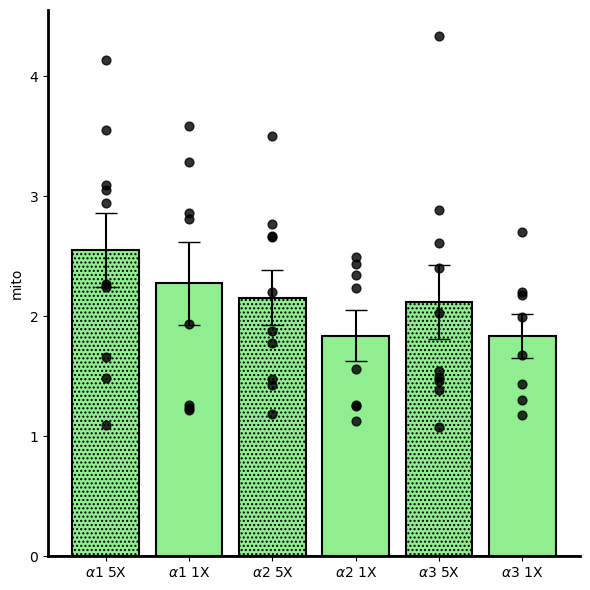

In [74]:
plot_bars_with_sem3([
                    mito_a1_5x_all,
                     mito_a1_1x_all,
                     mito_a2_5x_all,
                     mito_a2_1x_all,
                     mito_a3_5x_all,
                     mito_a3_1x_all,
                     
                     ],
                    labels = [
                   r'$\alpha$1 5X',
                        r'$\alpha$1 1X', 
                        r'$\alpha$2 5X',
                        r'$\alpha$2 1X', 
                        r'$\alpha$3 5X',
                        r'$\alpha$3 1X',       
                        
                        
                        ], ylabel="mito", figsize=(6,6),
                       bar_color=["lightgreen"], dot_color="black", spine_width=2, pattern = ['....', ''])

group: $\alpha$1 5X, mean: 1.6099777429054325, sem: 0.12326724111493445
group: $\alpha$1 1X, mean: 1.4839040142350703, sem: 0.0995033637233116
group: $\alpha$2 5X, mean: 1.5060322179654058, sem: 0.10254425920509325
group: $\alpha$2 1X, mean: 1.3595252141103806, sem: 0.052435790482212835
group: $\alpha$3 5X, mean: 1.7979959971787327, sem: 0.14470171551325298
group: $\alpha$3 1X, mean: 1.646205330785291, sem: 0.16413808376382383


<Axes: ylabel='BRP'>

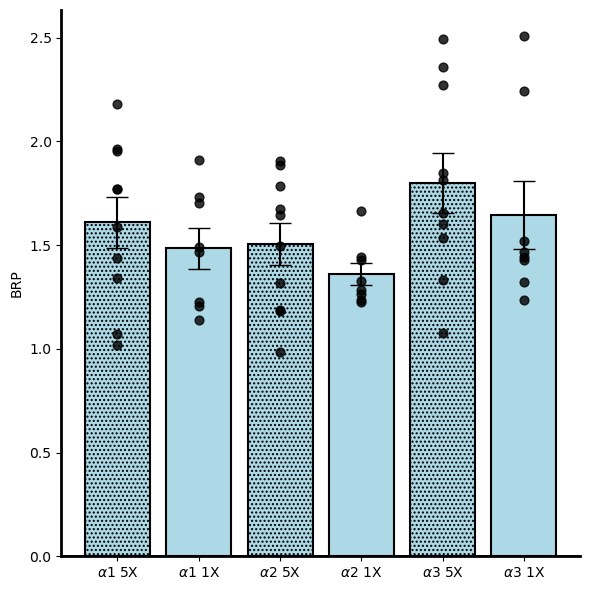

In [72]:
plot_bars_with_sem3([
                    brp_a1_5x_all,
                     brp_a1_1x_all,
                     brp_a2_5x_all,
                     brp_a2_1x_all,
                     brp_a3_5x_all,
                     brp_a3_1x_all,
                     
                     ],
                    labels = [
                    r'$\alpha$1 5X',
                        r'$\alpha$1 1X', 
                        r'$\alpha$2 5X',
                        r'$\alpha$2 1X', 
                        r'$\alpha$3 5X',
                        r'$\alpha$3 1X',       
                        
                        
                        ], ylabel="BRP", figsize=(6,6),
                       bar_color=["lightblue"], dot_color="black", spine_width=2, pattern = ['....', ''])

<h1>   RAW

group: $\alpha$1 5X, mean: 42.93853940451814, sem: 5.086400335139933
group: $\alpha$1 1X, mean: 61.88172114327302, sem: 9.442185574608038
group: $\alpha$2 5X, mean: 41.5957987634873, sem: 4.617540372370372
group: $\alpha$2 1X, mean: 57.02195479510457, sem: 8.545362786528054
group: $\alpha$3 5X, mean: 48.36249341076605, sem: 7.151313826046859
group: $\alpha$3 1X, mean: 54.5145837953471, sem: 7.221537159395804


<Axes: ylabel='HSP70 (a.u)'>

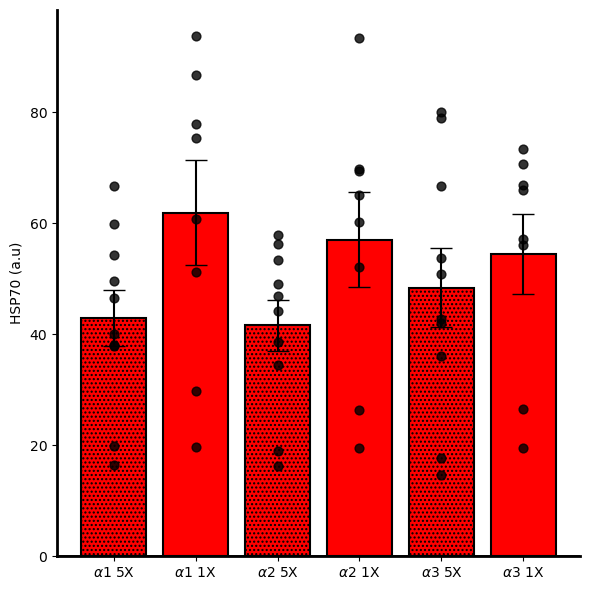

In [ ]:

plot_bars_with_sem3([
                    hsp_a1_5x_all_r,
                     hsp_a1_1x_all_r,
                     hsp_a2_5x_all_r,
                     hsp_a2_1x_all_r,
                     hsp_a3_5x_all_r,
                     hsp_a3_1x_all_r,
                     
                     ],
                    labels = [
                        r'$\alpha$1 5X',
                        r'$\alpha$1 1X', 
                        r'$\alpha$2 5X',
                        r'$\alpha$2 1X', 
                        r'$\alpha$3 5X',
                        r'$\alpha$3 1X',                           
           
                        
                        
                        ], ylabel="HSP70 (a.u)", figsize=(6,6),
                       bar_color=["red"], dot_color="black", spine_width=2,
                       pattern = ['....', ''])

In [ ]:
colors = ['cyan', 'blue']


['cyan', 'blue', 'cyan', 'blue', 'cyan', 'blue']


group: $\alpha$1 5X, mean: 13.124356458998012, sem: 0.65286929243576
group: $\alpha$1 1X, mean: 12.113081737508043, sem: 1.5673342786321132
group: $\alpha$2 5X, mean: 11.315496566831317, sem: 0.5409146016688923
group: $\alpha$2 1X, mean: 9.873989188388869, sem: 1.0106176549192005
group: $\alpha$3 5X, mean: 10.957066620311736, sem: 0.8663606336266674
group: $\alpha$3 1X, mean: 9.926221217077085, sem: 1.0168812026667995


<Axes: ylabel='mito'>

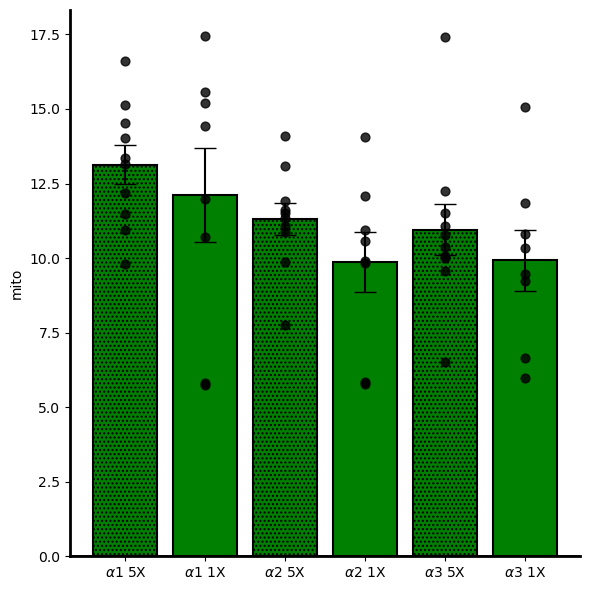

In [76]:



plot_bars_with_sem3([
                    mito_a1_5x_all_r,
                     mito_a1_1x_all_r,
                     mito_a2_5x_all_r,
                     mito_a2_1x_all_r,
                     mito_a3_5x_all_r,
                     mito_a3_1x_all_r,
                     
                     ],
                    labels = [
                      r'$\alpha$1 5X',
                        r'$\alpha$1 1X', 
                        r'$\alpha$2 5X',
                        r'$\alpha$2 1X', 
                        r'$\alpha$3 5X',
                        r'$\alpha$3 1X',       
                        
                        
                        ], ylabel="mito", figsize=(6,6),
                       bar_color=["green"], dot_color="black", spine_width=2, pattern = ['....', ''])

group: $\alpha$1 5X, mean: 8.790761069196817, sem: 0.7102931867649425
group: $\alpha$1 1X, mean: 8.341100450707602, sem: 1.1593450785497847
group: $\alpha$2 5X, mean: 8.460816781877146, sem: 0.9755389805248411
group: $\alpha$2 1X, mean: 7.793028464500055, sem: 1.1899854837230737
group: $\alpha$3 5X, mean: 10.266500795549499, sem: 1.3867092763073807
group: $\alpha$3 1X, mean: 10.096442881664178, sem: 2.4247874074048856


<Axes: ylabel='BRP'>

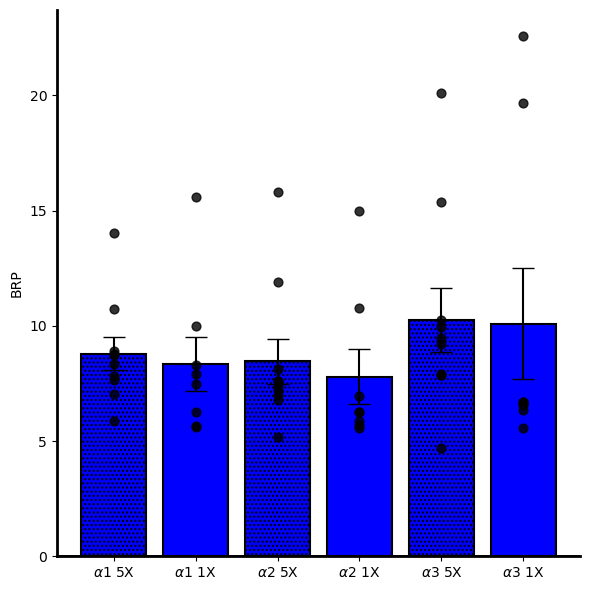

In [77]:
plot_bars_with_sem3([
                    brp_a1_5x_all_r,
                     brp_a1_1x_all_r,
                     brp_a2_5x_all_r,
                     brp_a2_1x_all_r,
                     brp_a3_5x_all_r,
                     brp_a3_1x_all_r,
                     
                     ],
                    labels = [
                 r'$\alpha$1 5X',
                        r'$\alpha$1 1X', 
                        r'$\alpha$2 5X',
                        r'$\alpha$2 1X', 
                        r'$\alpha$3 5X',
                        r'$\alpha$3 1X',       
                        
                        ], ylabel="BRP", figsize=(6,6),
                       bar_color=["blue"], dot_color="black", spine_width=2, pattern = ['....', ''])

group: 5X, mean: 5.786840252431697, sem: 0.6855998760097376
group: 1X, mean: 5.666359070340491, sem: 0.713948671839941


<Axes: ylabel='Antennal Lobe'>

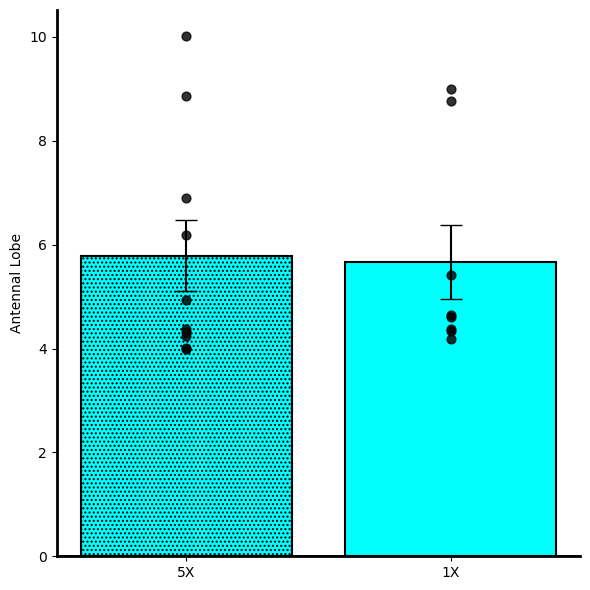

In [65]:
plot_bars_with_sem3([
                    al_5x_all_r,
                     al_1x_all_r,
                     
                     
                     ],
                    labels = [
                        '5X',
                        '1X',
                       
                        
                        
                        ], ylabel="Antennal Lobe", figsize=(6,6),
                       bar_color=["cyan"], dot_color="black", spine_width=2, pattern = ['....', ''])